BD, em def set_hpc(hpc), hpc= cpu
BD, em hiperblas_wrapper.c, py_init_engine, lib_name =/home/jovyan/local/lib/libhiperblas-cpu-bridge.so
BD, em /home/jovyan/hiperwalk/hiperblas-core/src/libhiperblas.c, load_plugin 
BD, so library name: /home/jovyan/local/lib/libhiperblas-cpu-bridge.so, 
bd, em coined.py, __init__
graph: <hiperwalk.graph.graph.Graph object at 0x71364adca710>
kwargs: {'shift': 'persistent', 'coin': 'G'}

_set_shift     :   Tempo decorrido: 0.001093 segundos

_set_coin      :   Tempo decorrido: 0.000009 segundos

_set_marked    :   Tempo decorrido: 0.000017 segundos
bd, em hiperwalk/quantum_walk/coined.py: def _set_evolution
BD, em hiperwalk/quantum_walk/coined.py: get_coin(self)

_set_evolution :   Tempo decorrido: 0.001024 segundos

bd, em coined.py: def state
bd, em hiperwalk/quantum_walk/quantum_walk.py:    def simulate
bd, start=1, end=7, step=2
bd, em quantum_walk.py: def _prepare_engine(self, state, hpc =  cpu
BD, em hiperwalk/quantum_walk/_pyhiperblas_interface.p

WhileIt  : Tempo decorrido: 0.000509 segundos


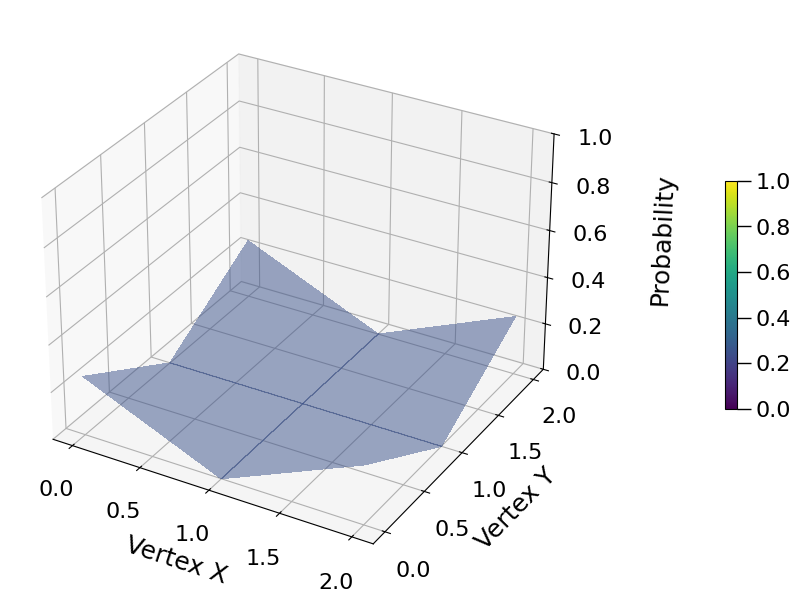

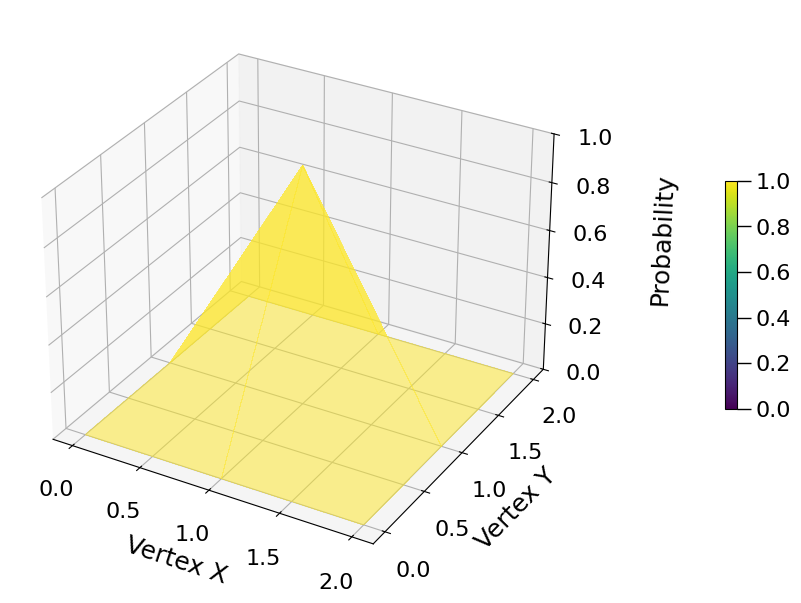

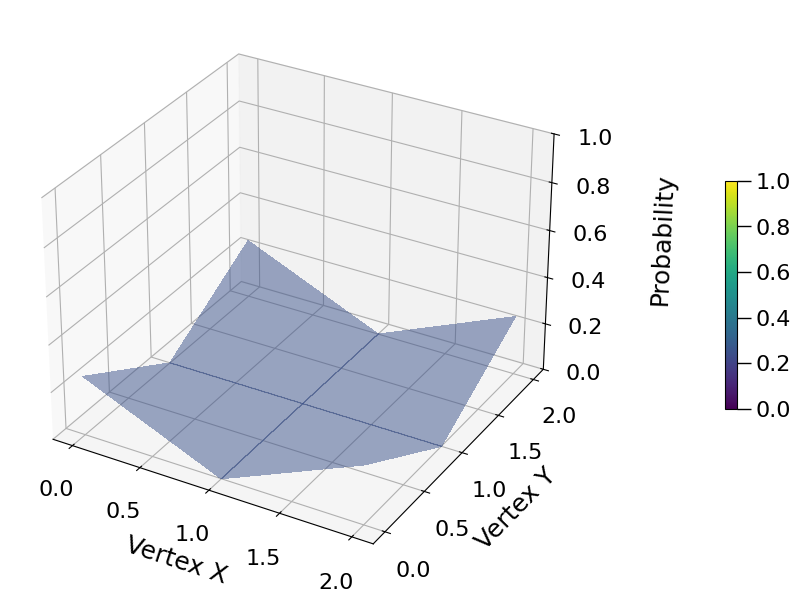

[[0.25 0.   0.25 0.   0.   0.   0.25 0.   0.25]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.25 0.   0.25 0.   0.   0.   0.25 0.   0.25]]
BD, ATENCAO !!! em hiperblas_wrapper.c, py_sparse_matrix_delete
BD, ATENCAO, em /home/jovyan/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c: void smatrix_delete, only the instance of struct smatrix_t 
BD, ATENCAO, em /home/jovyan/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-vector.c: void vector_delete( vector_t * v ), only the instance of struct vector_t
BD, ATENCAO, em /home/jovyan/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-vector.c: void vector_delete( vector_t * v ), only the instance of struct vector_t
Tue Mar 31 04:26:56 PM UTC 2026


In [1]:
import hiperwalk as hpw
import numpy as np

#nbl.init_engine(nbl.CPU,0)

import time
#import sys
#sys.stdout.reconfigure(line_buffering=False, write_through=False)
#sys.stdout.reconfigure(line_buffering=True)

aDim=3; aNumSteps=3; aCoin="F"; aHPCoPTION="cpu"
aDim=3; aNumSteps=3; aCoin="F"; aHPCoPTION=None
aDim=3; aNumSteps=3; aCoin="G"; aHPCoPTION=None
aDim=3; aNumSteps=6; aCoin="G"; aHPCoPTION="cpu"


dim          =aDim        # 10
myCoin         =aCoin       # "G" Grover para Real e  "F"  Fourier para Complex
myHPC_option =aHPCoPTION  # None   "cpu"    "gpu"
myNumSteps   =aNumSteps

coinT  = "Grover  coin,    real" if myCoin=="G"            else "Fourier coin, complex"
algebra="SciPy"                  if myHPC_option == None else "HiperBlas"

startStep=1;endStep=startStep+myNumSteps;step=2
aRange=(startStep,endStep,step)

from warnings import warn
def main():

    hpw.set_hpc(myHPC_option)

    inicioG = time.perf_counter()
    grid = hpw.Grid(dim, diagonal=True, periodic=False)
    fimG    = time.perf_counter()

    inicioC = time.perf_counter()
    dtqw = hpw.Coined(grid, shift='persistent', coin=myCoin)
    fimC = time.perf_counter()

    center = np.array([dim // 2, dim // 2])
    psi0 = dtqw.state([[0.5, (center, center + (1, 1))],
                   [-0.5, (center, center + (1, -1))],
                   [-0.5, (center, center + (-1, 1))],
                   [0.5, (center, center + (-1, -1))]])
    inicioS = time.perf_counter()
    for r in range(1): #50*1000*1000):
        psi_final = dtqw.simulate(range_=aRange, state=psi0)
    fimS = time.perf_counter()
    #print(f"Hypercube: Tempo decorrido: {fimG - inicioG:.6f} segundos", file=sys.stderr)
    #print(f"computeU : Tempo decorrido: {fimC - inicioC:.6f} segundos", file=sys.stderr)
    #print(f"Iteracoes: Tempo decorrido: {fimS - inicioS:.6f} segundos", file=sys.stderr)
    #print(f"Tempo total      decorrido: {fimS - inicioG:.6f} segundos", file=sys.stderr)

    U = dtqw.get_evolution(); num_arcs=U.shape[0]; densidade=U.nnz/(num_arcs*num_arcs)
    import os
    #nome=os.path.splitext(os.path.basename(__file__))[0] # sem extensão
    nome = "diagonal-grid_Dim3.ipynb"
    print(
    f"{nome:14s}, "
    f"dim = {dim:4d}, "
    f"numStep = {endStep - startStep:4d}, "
    f"{coinT}, "
    f"numArcs = {num_arcs:10d}, "
    f"nnz = {U.nnz:12d}, "
    f"densidade = {densidade:.5e}, "
    f"algebra = {algebra:>10s}, "
    f"OMP_NUM_THREADS = {os.getenv('OMP_NUM_THREADS') or 'ND':>3s}, "
    f"tempo computeU = {fimC - inicioC:.5e}, "
    f"tempo Iteracoes = {(fimS - inicioS) / (endStep - startStep + 1):.5e}, "
    f"tempo total     = {(fimS - inicioG) :.5e}")
    print('\n')
    #return
    np.set_printoptions(linewidth=820, threshold=240)
    probs = dtqw.probability_distribution(psi_final)
    print("prob = \n", probs)
    print("np.sum(prob) = ", np.sum(probs))
    
    hpw.plot_probability_distribution(probs, graph=grid)
    

    print(probs)
    #plt.savefig("grafico.png")

if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        import traceback
        print("Erro:", e, file=sys.stderr)
        traceback.print_exc()
        
!date
#main()